In [2]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)
# Daily Return

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [3]:
returns = (
    nav.groupby("amfi_code")
    ["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std"
    )
)

returns.head()

,mean_return,std_return
amfi_code,,
100016,0.000142,0.009164
100025,0.000170,0.002460
100033,0.001080,0.011929
101206,0.000852,0.009177
101207,0.000424,0.016251


In [5]:
annual_returns = []

for code, group in nav.groupby("amfi_code"):

    daily = group["daily_return"].dropna()

    n = len(daily)

    if n > 0:

        annual_return = (
            (1 + daily).prod()
        ) ** (252 / n) - 1

        annual_returns.append(
            [code, annual_return]
        )

annual_df = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annualized_return"
    ]
)
annual_df.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)
annual_df.head()

,amfi_code,annualized_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [6]:
performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print(
    performance[
        ["scheme_name","amfi_code"]
    ].head()
)

                                    scheme_name  amfi_code
0     SBI Bluechip Fund - Regular Plan - Growth     119551
1      SBI Bluechip Fund - Direct Plan - Growth     119552
2    SBI Small Cap Fund - Regular Plan - Growth     119598
3     SBI Small Cap Fund - Direct Plan - Growth     119599
4  SBI Magnum Gilt Fund - Regular Plan - Growth     119120


In [7]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

cagr_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] -
         group.iloc[0]["date"]).days
    ) / 365.25

    if years > 0:

        cagr = (
            (end_nav / start_nav)
            ** (1 / years)
        ) - 1

        cagr_results.append(
            [code, cagr]
        )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)
cagr_df.head()

,amfi_code,cagr,scheme_name
0,100016,0.026371,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.044582,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.301232,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.235384,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.079388,ABSL Small Cap Fund - Regular - Growth


In [10]:
import pandas as pd

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print(nav.head())
print(nav.columns)

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')


In [12]:
risk_free_rate = 0.065

sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    daily_returns = group["daily_return"].dropna()

    if len(daily_returns) > 0:

        annual_return = (
            (1 + daily_returns).prod()
        ) ** (252 / len(daily_returns)) - 1

        annual_volatility = (
            daily_returns.std()
            * np.sqrt(252)
        )

        sharpe = (
            annual_return -
            risk_free_rate
        ) / annual_volatility

        sharpe_results.append(
            [code, sharpe]
        )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.271960
1,100025,-0.563690
2,100033,1.184359
3,101206,1.106967
4,101207,0.044584


In [13]:
sortino_results = []

for code, group in nav.groupby("amfi_code"):

    daily_returns = (
        group["daily_return"]
        .dropna()
    )

    negative_returns = (
        daily_returns[
            daily_returns < 0
        ]
    )

    if len(negative_returns) > 0:

        annual_return = (
            (1 + daily_returns).prod()
        ) ** (252 / len(daily_returns)) - 1

        downside_std = (
            negative_returns.std()
            * np.sqrt(252)
        )

        sortino = (
            annual_return -
            risk_free_rate
        ) / downside_std

        sortino_results.append(
            [code, sortino]
        )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.473761
1,100025,-0.936166
2,100033,1.980757
3,101206,1.939283
4,101207,0.075827


In [14]:
print(sharpe_df.shape)
print(sortino_df.shape)

(40, 2)
(40, 2)


In [15]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip.csv', 'HDFC_Top100_Live_NAV.csv', 'ICICI_Bluechip.csv', 'Kotak_Bluechip.csv', 'Nippon_LargeCap.csv', 'SBI_Bluechip.csv']


In [16]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [17]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Use NIFTY100 as benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [18]:
alpha_beta_results = []

for code, group in nav.groupby("amfi_code"):

    fund = group.copy()

    merged = pd.merge(
        fund,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r, p, stderr = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [19]:
print(alpha_beta_df.shape)

(40, 3)


In [20]:
max_dd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    max_dd_results.append(
        [code, max_dd]
    )

max_dd_df = pd.DataFrame(
    max_dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)
max_dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [21]:
print(max_dd_df.shape)


(40, 2)


In [22]:
scorecard = performance[
    ["amfi_code", "scheme_name", "return_3yr_pct", "expense_ratio_pct"]
].copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_dd_df,
    on="amfi_code"
)

scorecard.head()
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)
scorecard["fund_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)
scorecard["fund_score"] = (
    (
        scorecard["fund_score"].max()
        - scorecard["fund_score"]
    )
    /
    (
        scorecard["fund_score"].max()
        - scorecard["fund_score"].min()
    )
) * 100
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    ["scheme_name", "fund_score"]
].head(10)
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Created Successfully")

Fund Scorecard Created Successfully


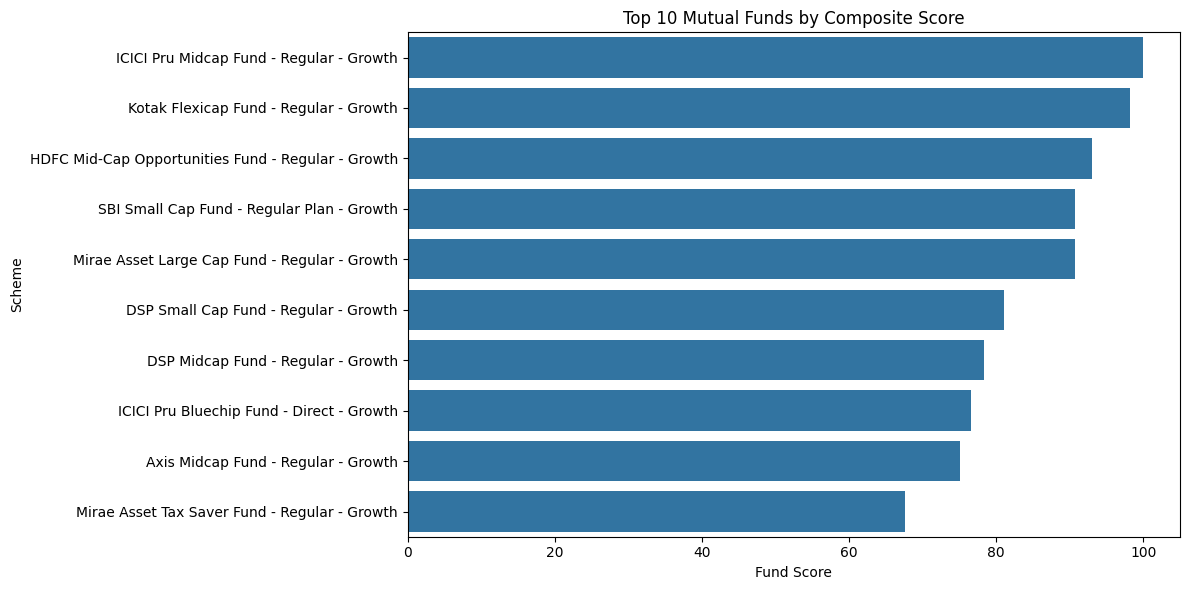

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig(
    "../reports/top10_fund_scorecard.png"
)

plt.show()

[120505, 119598, 149324, 148569, 148567]


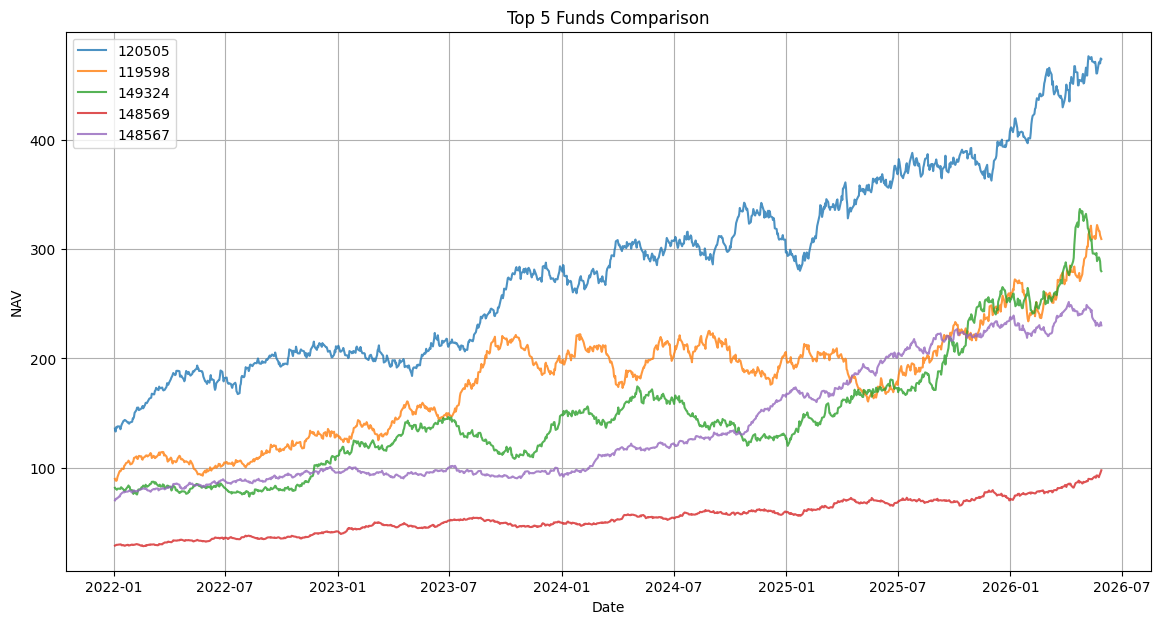

In [24]:
top5 = (
    cagr_df
    .sort_values(
        "cagr",
        ascending=False
    )
    .head(5)
)

top5_codes = (
    top5["amfi_code"]
    .tolist()
)

print(top5_codes)
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for code in top5_codes:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.8,
        label=str(code)
    )
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)
plt.title(
    "Top 5 Funds Comparison"
)

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.grid(True)

plt.show()